In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load ---
path = "data_transportation_faculty.xlsx"
people = pd.read_excel(path, sheet_name="People")

In [2]:
people['UG_Country'].value_counts()

USA                     180
China                   112
India                    31
Iran                     29
Egypt                    17
South Korea              15
Bangladesh               14
Greece                   14
Turkey                   14
Canada                    8
Colombia                  8
Serbia                    5
Taiwan                    5
Jordan                    5
Lebanon                   5
Ghana                     4
Tanzania                  4
Italy                     3
Pakistan                  3
England                   3
France                    3
Sri Lanka                 3
Poland                    3
Chile                     2
Russia                    2
Nigeria                   2
Sudan                     2
Argentina                 2
Israel                    2
Spain                     2
Singapore                 1
Brazil                    1
Haiti                     1
Iraq                      1
Sweden                    1
Finland             

In [3]:
import pandas as pd
import numpy as np

# Start by copying the original column
people['Origin_Group'] = people['UG_Country']

# Countries kept as their own group (>=10 rule)
keep_as_is = [
    'USA',
    'China',
    'India',
    'Iran',
    'Egypt',
    'South Korea',
    'Bangladesh',
    'Greece',
    'Turkey',
    'Canada'
]

# Europe (other)
europe_other = [
    'England', 'France', 'Italy', 'Poland', 'Spain', 'Serbia',
    'Switzerland', 'Sweden', 'Finland', 'Denmark'
]

# Latin / South America
latin_south_america = [
    'Argentina', 'Brazil', 'Chile', 'Colombia', 'Peru',
    'Uruguay', 'Venezuela', 'Dominican Republic'
]

# Africa (excluding Egypt, which is its own group)
africa = [
    'Ghana', 'Nigeria', 'Sudan', 'Tanzania'
]

# Apply regional groupings
people.loc[people['UG_Country'].isin(europe_other), 'Origin_Group'] = 'Europe (other)'
people.loc[people['UG_Country'].isin(latin_south_america), 'Origin_Group'] = 'Latin / South America'
people.loc[people['UG_Country'].isin(africa), 'Origin_Group'] = 'Africa'

# Everything else that is not in keep_as_is and not missing -> Other origins
mask_other = (
    ~people['UG_Country'].isin(keep_as_is)
    & ~people['UG_Country'].isin(europe_other)
    & ~people['UG_Country'].isin(latin_south_america)
    & ~people['UG_Country'].isin(africa)
    & people['UG_Country'].notna()
)

people.loc[mask_other, 'Origin_Group'] = 'Other origins'

# Explicitly label missing
people.loc[people['UG_Country'].isna(), 'Origin_Group'] = 'Missing / Unknown'


In [4]:
people['Origin_Group'].value_counts(dropna=False)

USA                      180
China                    112
Missing / Unknown         36
Other origins             31
India                     31
Iran                      29
Europe (other)            23
Latin / South America     17
Egypt                     17
South Korea               15
Greece                    14
Turkey                    14
Bangladesh                14
Africa                    12
Canada                     8
Name: Origin_Group, dtype: int64

# Secion 4 

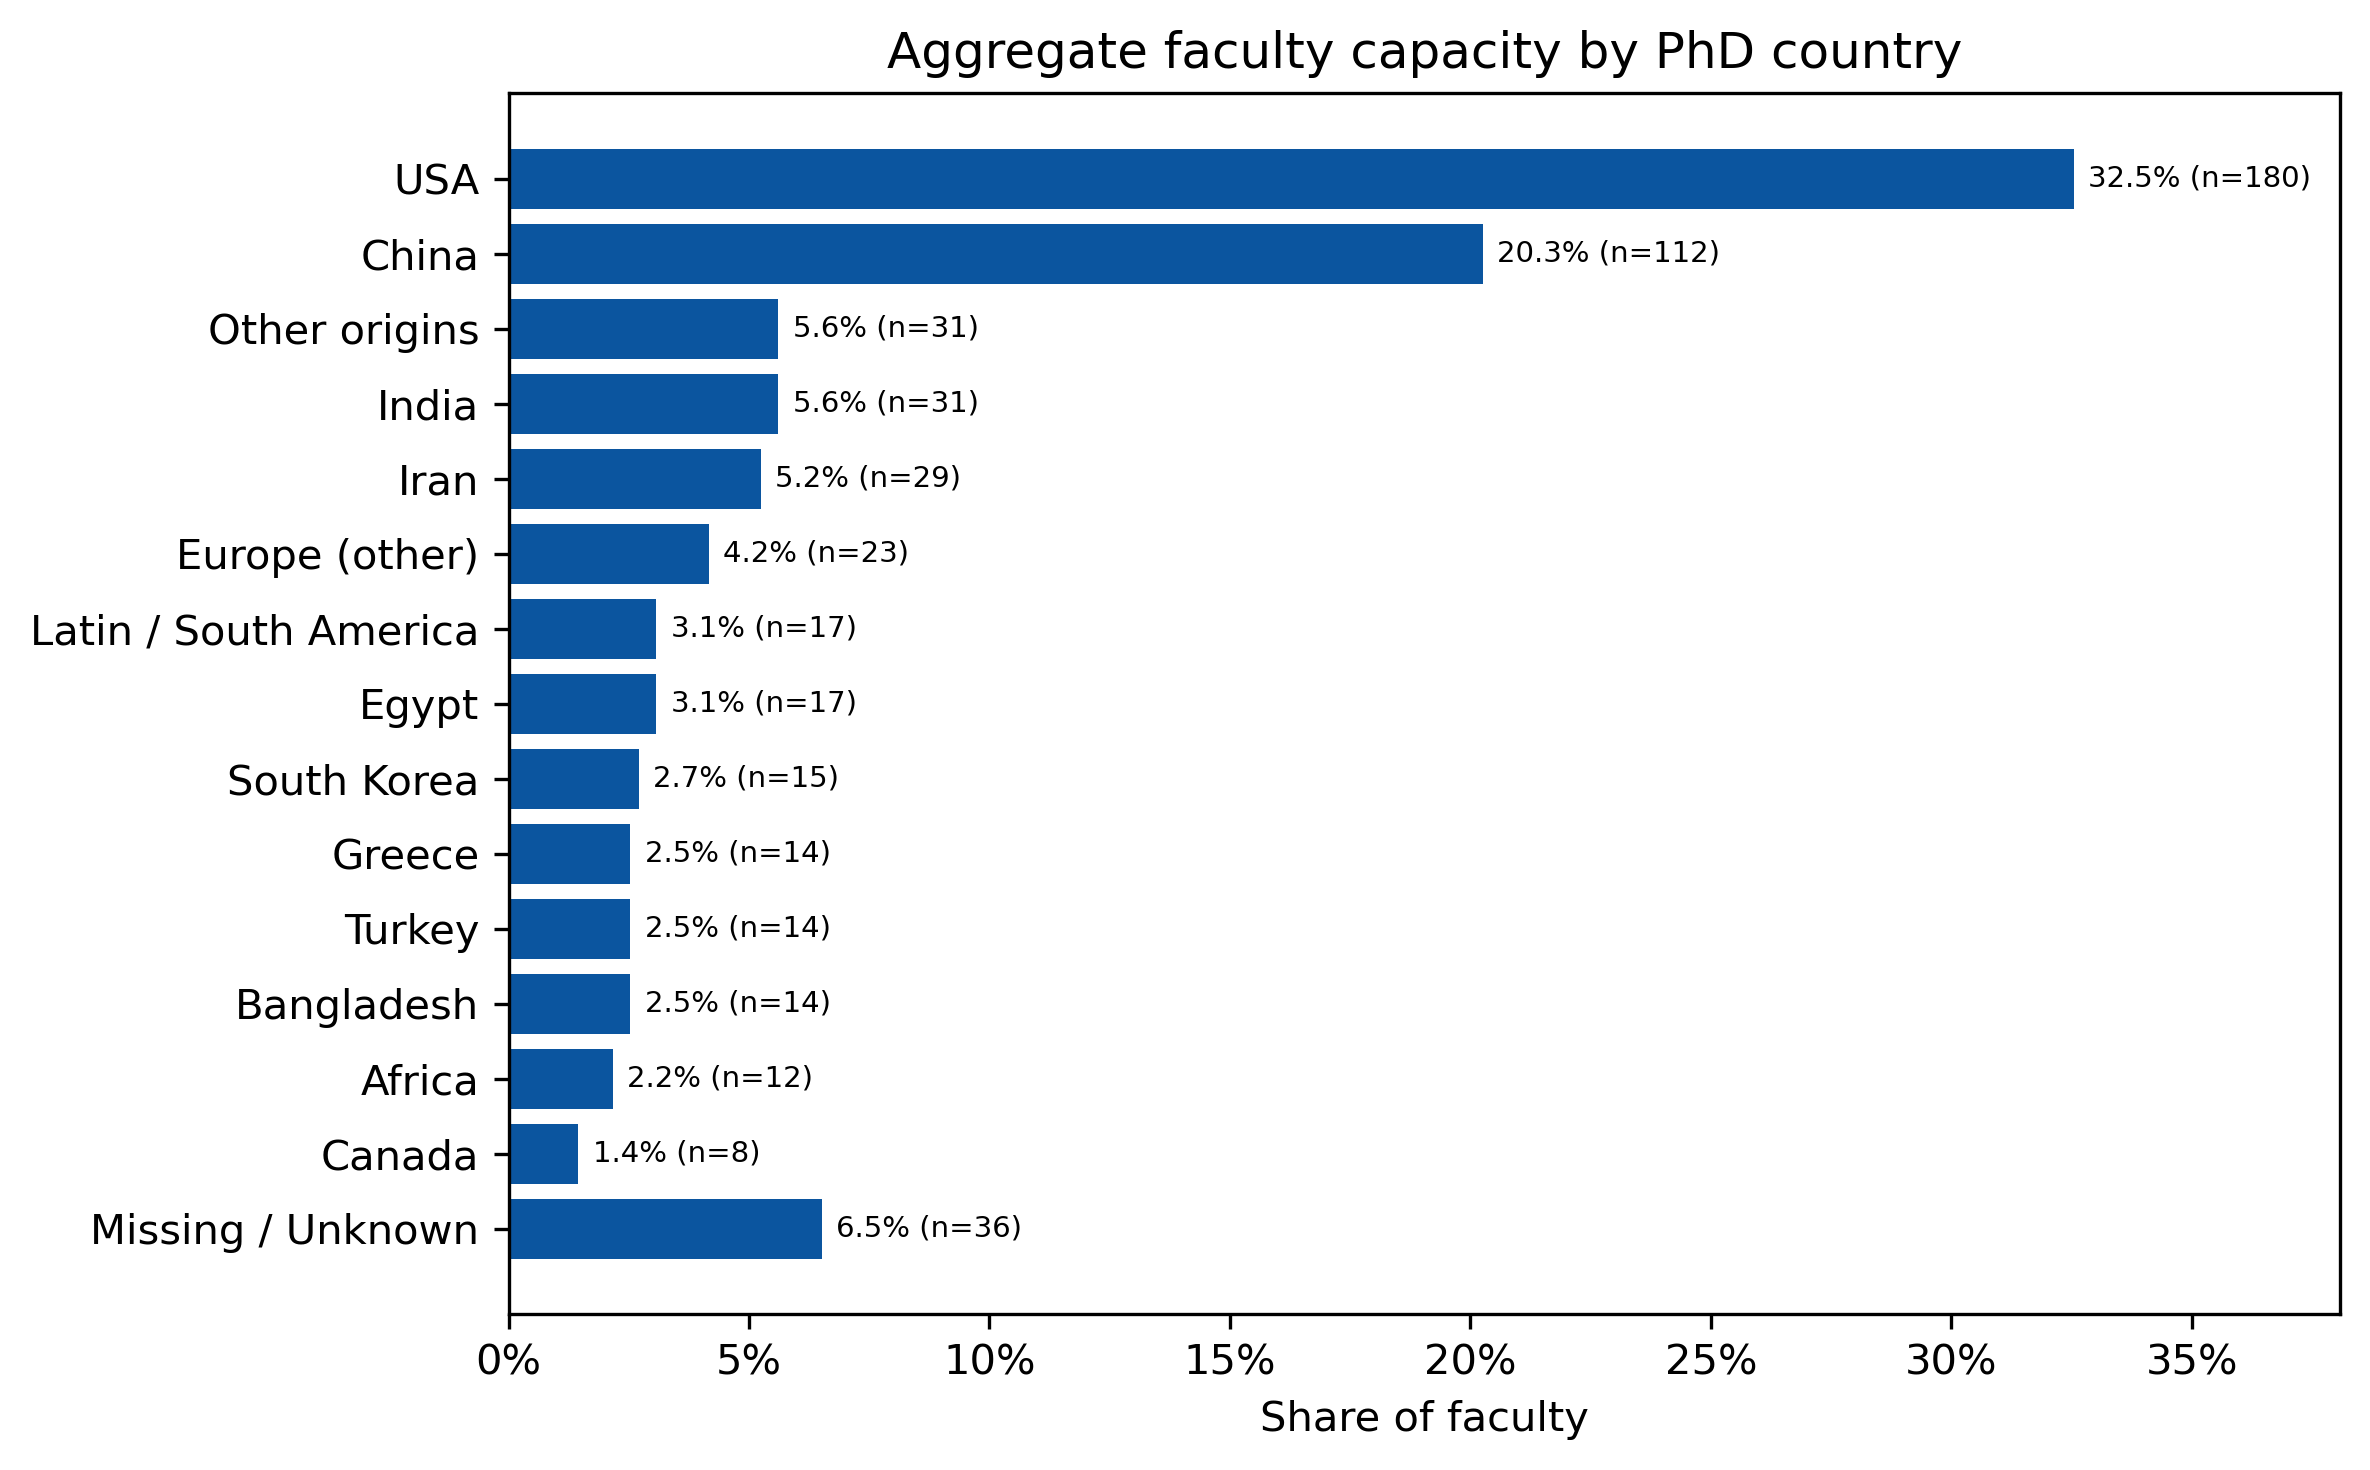

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

df = people.copy()

counts = df["Origin_Group"].value_counts()
shares = counts / counts.sum()

label_to_push = "Missing / Unknown"

# Sort descending for readability
order = shares.sort_values(ascending=False).index.tolist()

# Remove missing then append it at the end of the list
if label_to_push in order:
    order = [x for x in order if x != label_to_push] + [label_to_push]

counts = counts.loc[order]
shares = shares.loc[order]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.set_facecolor("white")

ax.barh(shares.index.astype(str), shares.values, color="#0b559f")

# Make the first item appear at the top (so descending looks natural)
ax.invert_yaxis()

ax.set_title("Aggregate faculty capacity by PhD country")
ax.set_xlabel("Share of faculty")

xticks = np.arange(0, 0.36, 0.05)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x*100)}%" for x in xticks])

ax.set_xlim(0, shares.max() * 1.17)

for y, country in enumerate(shares.index):
    n = int(counts.loc[country])
    ax.text(shares.loc[country] + 0.003, y,
            f"{shares.loc[country]*100:.1f}% (n={n})",
            va="center", fontsize=7)

fig.tight_layout()
# fig.savefig(
#     "fig_origin_composition.png",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
#     edgecolor="white",
#     transparent=False,
# )
plt.show()


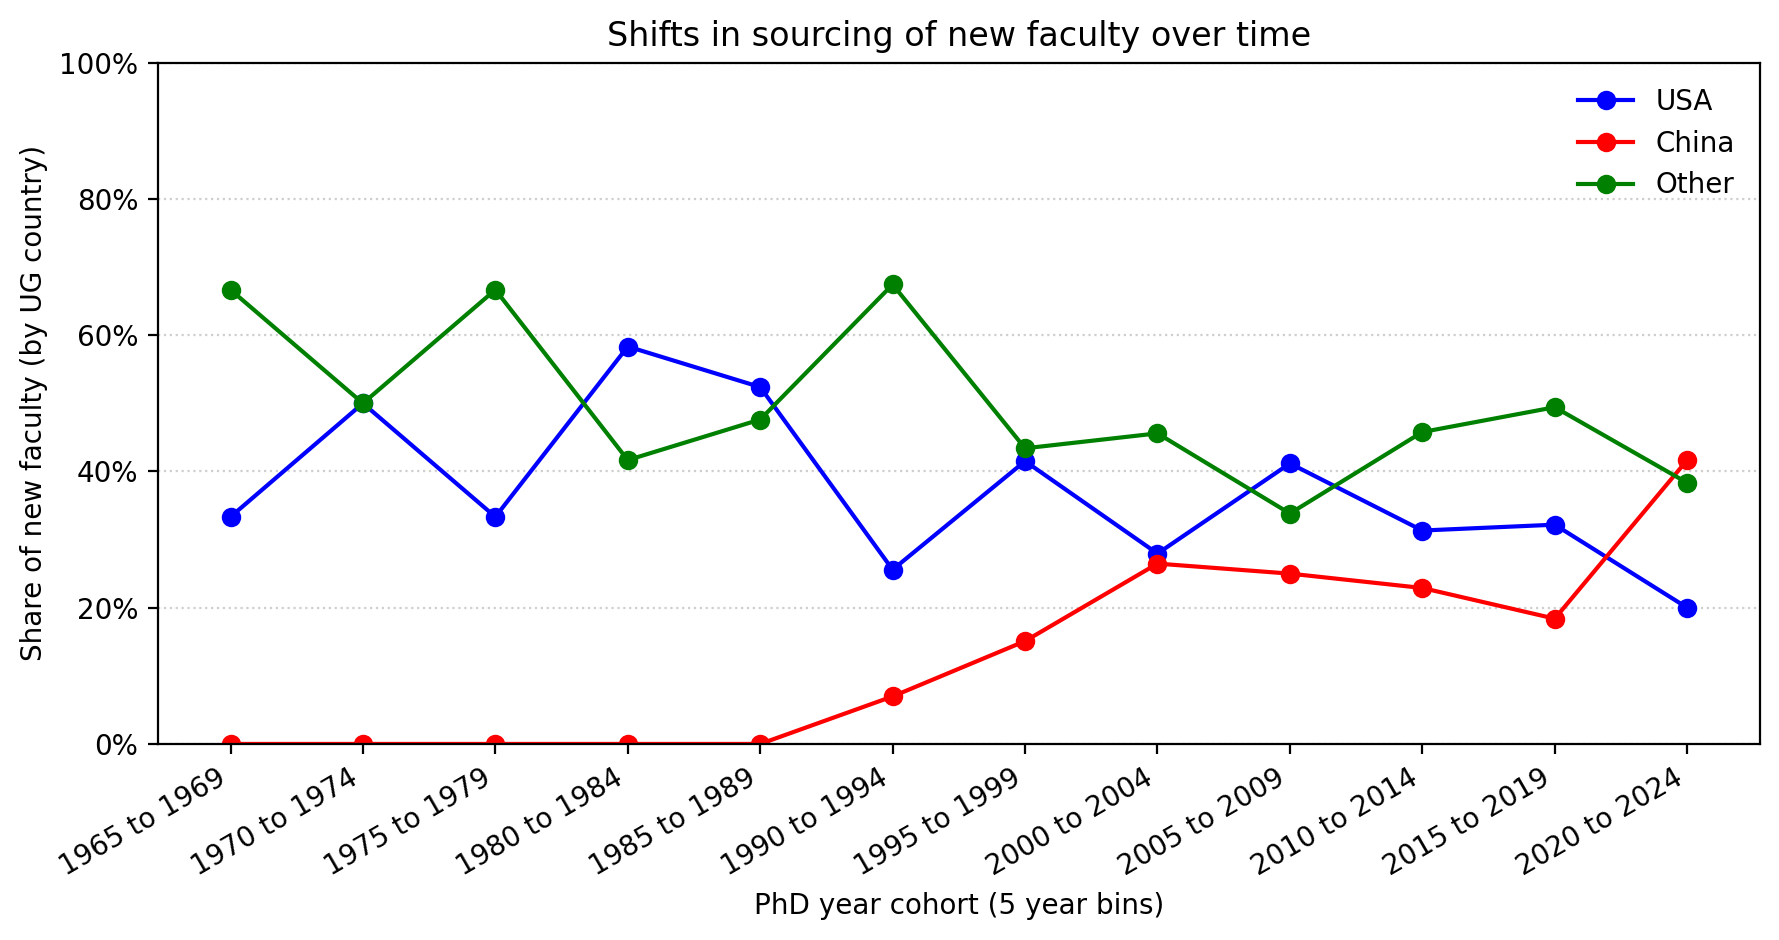

PhD_Year_Bin_Label
1965 to 1969     3
1970 to 1974     6
1975 to 1979     9
1980 to 1984    12
1985 to 1989    21
1990 to 1994    43
1995 to 1999    53
2000 to 2004    68
2005 to 2009    68
2010 to 2014    83
2015 to 2019    87
2020 to 2024    60
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

df = people.copy()

# ---- 1) Clean PhD year ----
df["PhD_Year"] = pd.to_numeric(df["PhD_Year"], errors="coerce")
df = df.dropna(subset=["PhD_Year"])
df["PhD_Year"] = df["PhD_Year"].astype(int)

# ---- 2) Map UG country to USA / China / Other ----
def to_3group_ug(x):
    if x == "USA":
        return "USA"
    elif x == "China":
        return "China"
    else:
        return "Other"

df["UG_Origin_3"] = df["UG_Country"].astype(str).apply(to_3group_ug)

# ---- 3) Build 5 year PhD cohorts ----
bin_start = int(np.floor(df["PhD_Year"].min() / 5) * 5)
# bin_end = int(np.ceil((df["PhD_Year"].max() + 1) / 5) * 5)
bin_start = 1965
bin_end = 2026

bins = list(range(bin_start, bin_end + 1, 5))

df["PhD_Year_Bin"] = pd.cut(df["PhD_Year"], bins=bins, right=False)

bin_labels = {
    b: f"{b.left} to {b.right - 1}"
    for b in df["PhD_Year_Bin"].cat.categories
}

df["PhD_Year_Bin_Label"] = df["PhD_Year_Bin"].map(bin_labels)

# ---- 4) Cohort shares by UG origin ----
tab = (
    df.groupby(["PhD_Year_Bin_Label", "UG_Origin_3"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=["USA", "China", "Other"], fill_value=0)
)

shares = tab.div(tab.sum(axis=1), axis=0)
cohort_n = tab.sum(axis=1)

# ---- 5) Plot ----
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=200, facecolor="white")
ax.set_facecolor("white")

x = np.arange(len(shares.index))

ax.plot(x, shares["USA"], marker="o", label="USA", color = 'blue')
ax.plot(x, shares["China"], marker="o", label="China", color = 'red')
ax.plot(x, shares["Other"], marker="o", label="Other", color = 'green')

ax.set_xticks(x)
ax.set_xticklabels(shares.index, rotation=30, ha="right")

ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(t*100)}%" for t in ax.get_yticks()])

ax.set_xlabel("PhD year cohort (5 year bins)")
ax.set_ylabel("Share of new faculty (by UG country)")
ax.set_title("Shifts in sourcing of new faculty over time")

ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.legend(frameon=False)

fig.tight_layout()
# fig.savefig(
#     "fig_entry_trends_ugcountry_phdyear_bins.png",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
#     edgecolor="white",
#     transparent=False
# )

plt.show()

# Optional: cohort sizes for caption / appendix
print(cohort_n)


In [7]:
import pandas as pd
import plotly.graph_objects as go

# Load
path = "data_transportation_faculty.xlsx"
people = pd.read_excel(path, sheet_name="People")
rank = pd.read_excel(path, sheet_name="University Rankings")

# If First_Hire is missing, treat First_Hire as Current_Institution
people["First_Hire_Filled"] = people["First_Hire"].fillna(people["Current_Institution"])

# Optional one off name fix (keep if you used it elsewhere)
people["First_Hire_Filled"] = people["First_Hire_Filled"].replace({
    "University at Buffalo": "University at Buffalo SUNY"
})
people["Current_Institution"] = people["Current_Institution"].replace({
    "University at Buffalo": "University at Buffalo SUNY"
})

# Map institution to tier
tier_map = rank.set_index("School")["US_News_Tier"].to_dict()
people["First_Hire_Tier"] = people["First_Hire_Filled"].map(tier_map).fillna("Not in US News sample")

# Region scheme from your notebook
keep_as_is = [
    "USA", "China", "India", "Iran", "Egypt", "South Korea",
    "Bangladesh", "Greece", "Turkey", "Canada"
]
europe_other = ["England", "France", "Italy", "Poland", "Spain", "Serbia", "Switzerland", "Sweden", "Finland", "Denmark"]
latin_south_america = ["Argentina", "Brazil", "Chile", "Colombia", "Peru", "Uruguay", "Venezuela", "Dominican Republic"]
africa = ["Ghana", "Nigeria", "Sudan", "Tanzania"]

def add_origin_group(df, country_col, out_col):
    df[out_col] = df[country_col]

    df.loc[df[country_col].isin(europe_other), out_col] = "Europe (other)"
    df.loc[df[country_col].isin(latin_south_america), out_col] = "Latin / South America"
    df.loc[df[country_col].isin(africa), out_col] = "Africa"

    mask_other = (
        ~df[country_col].isin(keep_as_is)
        & ~df[country_col].isin(europe_other)
        & ~df[country_col].isin(latin_south_america)
        & ~df[country_col].isin(africa)
        & df[country_col].notna()
    )
    df.loc[mask_other, out_col] = "Other origins"
    df.loc[df[country_col].isna(), out_col] = "Missing / Unknown"
    return df

# Apply to UG country
people = add_origin_group(people, "UG_Country", "UG_Origin_Group")

# Simplify origins
major_origins = {"USA", "China", "India", "Europe (other)"}
people["UG_Origin_Group_Coarse"] = people["UG_Origin_Group"].where(
    people["UG_Origin_Group"].isin(major_origins),
    "Other origins"
)

# Drop hires not in US News sample
people_s = people[people["First_Hire_Tier"] != "Not in US News sample"].copy()

# Build flows
flow = (
    people_s.groupby(["UG_Origin_Group_Coarse", "First_Hire_Tier"])
    .size()
    .reset_index(name="count")
)

# Remove tiny flows
min_flow = 3
flow = flow[flow["count"] >= min_flow].copy()

# Orders you want
origin_order = ["USA", "China", "India", "Europe (other)", "Other origins"]
origin_order = [o for o in origin_order if o in flow["UG_Origin_Group_Coarse"].unique()]

tier_order = [
    "Tier 1 (Top 15)",
    "Tier 2 (16–30)",
    "Tier 3 (31–60)",
    "Tier 4 (61–100)",
    "Tier 5 (100+)",
]
tier_order = [t for t in tier_order if t in flow["First_Hire_Tier"].unique()]

labels = origin_order + tier_order
idx = {lab: i for i, lab in enumerate(labels)}

source = flow["UG_Origin_Group_Coarse"].map(idx).tolist()
target = flow["First_Hire_Tier"].map(idx).tolist()
value  = flow["count"].tolist()

# ---- Force node positions ----
# x positions: origins left, tiers right
x = [0.01] * len(origin_order) + [0.99] * len(tier_order)

# y positions: explicitly top->bottom in your order
def spaced_y(n, top=0.02, bottom=0.98):
    if n == 1:
        return [0.5]
    step = (bottom - top) / (n - 1)
    return [top + i * step for i in range(n)]

y = spaced_y(len(origin_order)) + spaced_y(len(tier_order))

fig = go.Figure(go.Sankey(
    arrangement="fixed",
    node=dict(
        label=labels,
        x=x,
        y=y,
        pad=12,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(160,160,160,0.5)"
    )
))

fig.update_layout(
    title_text="Undergraduate country of origin and first U.S. faculty appointment tier",
    font_size=12
)

fig.show()

c:\Users\appuals\anaconda3\lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


